# 内积范数与正交投影

学习目标：用内积和范数描述长度、距离与夹角，构造正交投影，并以残差和平方范数核对几何关系。

前置知识：向量、线性组合、基、矩阵乘法与转置、平方根与余弦；Python 数组索引、循环与模块导入。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11；本章讨论有限维实向量与实矩阵。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 内积把两个向量变成一个数

把 $x=(3,4)^T$ 与 $y=(1,-2)^T$ 的对应分量相乘再求和，得到 $3\times1+4\times(-2)=-5$。这个数是本章使用的内积（inner product），也称点积（dot product）。

对列向量 $x,y\in\mathbb R^n$，其中 $n$ 为正整数，标准欧氏内积定义为

$$\langle x,y\rangle=x^Ty=\sum_{i=1}^{n}x_i y_i.$$

结果是标量；$x_i,y_i$ 是第 $i$ 个分量。它满足对称性 $x^Ty=y^Tx$ 和分配律 $x^T(y+z)=x^Ty+x^Tz$，其中 $z\in\mathbb R^n$。本章的长度与正交都以这个内积为准。

代码用形状为 (n,) 的一维数组保存分量；两个这样的数组用 @ 得到内积。数学上的列向量仍是 $n\times1$，不要把一维数组的形状当成列矩阵的形状。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([3.0, 4.0])
y = np.array([1.0, -2.0])

print("对应分量乘积：", x * y)  # [3, -8]，仍是数组。
print("内积：", x @ y)  # -5，与逐元素乘积求和一致。
print("逐项求和：", np.sum(x * y))  # 预期为 -5。
print("自身内积：", x @ x)  # 3² + 4² = 25。

对应分量乘积： [ 3. -8.]
内积： -5.0
逐项求和： -5.0
自身内积： 25.0


## 2 从内积得到长度、距离与夹角

### 2.1 长度与两点距离

向量 $x\in\mathbb R^n$ 的欧氏长度是 $\|x\|_2=\sqrt{x^Tx}$。它非负，只有零向量的长度为零。

把 $x,y$ 看成同一坐标系中的两点，两点的欧氏距离为 $d_2(x,y)=\|x-y\|_2$。例如 $x=(3,4)^T$ 的长度是 5，而它到 $y=(1,-2)^T$ 的距离是 $\sqrt{2^2+6^2}=\sqrt{40}$。点的位置和两点之间的位移是不同对象。

In [2]:
x = np.array([3.0, 4.0])
y = np.array([1.0, -2.0])
displacement = x - y

print("x 的长度：", np.sqrt(x @ x))  # 5。
print("位移：", displacement)  # [2, 6]。
print("两点距离：", np.linalg.norm(displacement))  # 约 6.325。

x 的长度： 5.0
位移： [2. 6.]
两点距离： 6.324555320336759


### 2.2 归一化需要非零向量

把非零向量除以它的长度，可以保留方向并得到单位向量：

$$u=\frac{x}{\|x\|_2},\qquad \|u\|_2=1.$$

例如 $(3,4)^T$ 变为 $(0.6,0.8)^T$。零向量没有可保留的方向，不能用除以零的方式归一化。下面把非零输入归一化，并单独计算零向量的长度，说明公式为什么不适用于它。

In [3]:
x = np.array([3.0, 4.0])
unit_x = x / np.linalg.norm(x)
print("单位向量：", unit_x)  # [0.6, 0.8]。
print("归一化后长度：", np.linalg.norm(unit_x))  # 1。

zero = np.zeros(2)
zero_length = np.linalg.norm(zero)
print("零向量长度：", zero_length)  # 0；没有单位方向，因此不代入归一化公式。

单位向量： [0.6 0.8]
归一化后长度： 1.0
零向量长度： 0.0


### 2.3 夹角需要两个非零向量

对非零的 $x,y\in\mathbb R^n$，夹角 $\theta\in[0,\pi]$ 用弧度表示，满足

$$\cos\theta=\frac{x^Ty}{\|x\|_2\|y\|_2}.$$

内积为正时 $0\leq\theta<\pi/2$，为零时 $\theta=\pi/2$，为负时 $\pi/2<\theta\leq\pi$；同向和反向的边界分别是 $0$ 与 $\pi$。例如 $(1,0)^T$ 与 $(1,1)^T$ 的余弦是 $1/\sqrt2$，夹角是 $\pi/4$，即 $45^\circ$。

np.arccos 返回弧度，np.degrees 转成角度。理论上的余弦属于 $[-1,1]$，这是反余弦的实数定义域。本例余弦约为 0.7071，直接代入；结果的末位差异来自浮点舍入。

In [4]:
x = np.array([1.0, 0.0])
y = np.array([1.0, 1.0])
length_x = np.linalg.norm(x)
length_y = np.linalg.norm(y)

# 本例两个输入均非零，余弦位于反余弦的定义域内。
cosine = (x @ y) / (length_x * length_y)
angle = np.arccos(cosine)
print("余弦：", cosine)  # 约 0.7071。
print("夹角（度）：", np.degrees(angle))  # 45。

余弦： 0.7071067811865475
夹角（度）： 45.00000000000001


## 3 范数决定怎样度量距离

### 3.1 三种常见向量范数

范数（norm）把向量映射为非负大小，并满足三个要求：只有零向量的范数为零；数乘满足 $\|a x\|=|a|\|x\|$；相加满足三角不等式 $\|x+y\|\leq\|x\|+\|y\|$。这里 $a\in\mathbb R$，$x,y\in\mathbb R^n$。

对实数参数 $p\geq1$，$p$ 范数是 $\|x\|_p=(\sum_{i=1}^{n}|x_i|^p)^{1/p}$；无穷范数单独用最大绝对分量定义。

| 原文名称 | 中文名称／含义 | 定义 |
| --- | --- | --- |
| L1 norm | 1 范数，累计绝对分量 | $\|x\|_1=\sum_{i=1}^{n}\lvert x_i\rvert$ |
| L2 norm | 2 范数，欧氏长度 | $\|x\|_2=\sqrt{\sum_{i=1}^{n}x_i^2}$ |
| Infinity norm | 无穷范数，最大绝对分量 | $\|x\|_\infty=\max_{1\leq i\leq n}\lvert x_i\rvert$ |

每一种范数都给出相应距离 $d(x,y)=\|x-y\|$。同一位移 $(3,-4)^T$ 的三种大小是 7、5、4；描述误差时必须说明采用哪一种。

In [5]:
x = np.array([3.0, -4.0])
origin = np.zeros(2)

for order in (1, 2, np.inf):
    print(f"范数阶数 {order}，到原点的距离：", np.linalg.norm(x - origin, ord=order))  # 1、2、∞ 范数依次为 7、5、4。
# 依次为 7、5、4；这反映三种度量方式，并非同一计算的误差。

范数阶数 1，到原点的距离： 7.0
范数阶数 2，到原点的距离： 5.0
范数阶数 inf，到原点的距离： 4.0


### 3.2 用等值线观察单位距离

二维平面中的集合 $\{x\in\mathbb R^2:\|x\|=1\}$ 包含到原点的范数距离恰好为 1 的点。把三种定义代入，得到菱形、圆与正方形；曲线内部满足 $\|x\|<1$。

下面的示意图只改变范数，坐标范围和纵横比例保持一致。np.meshgrid 生成二维坐标网格，contour 的 levels=[1.0] 画出数值为 1 的等值线。坐标为无量纲示例值。

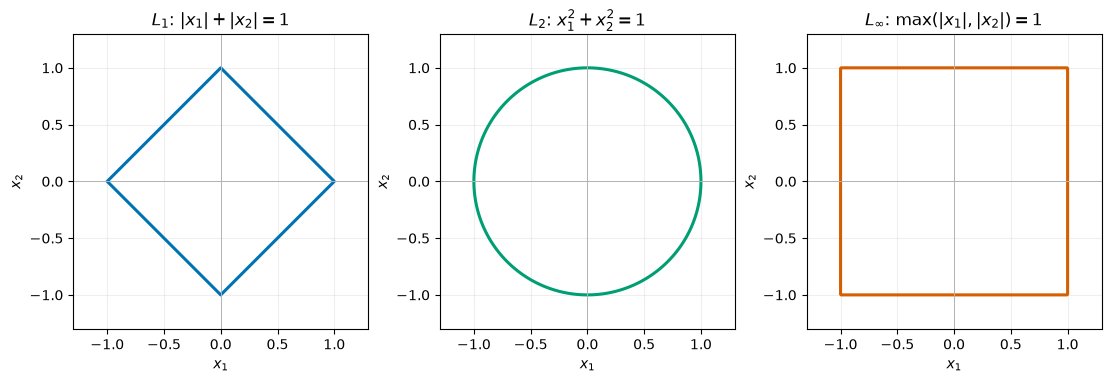

In [6]:
# 在同一二维网格上计算三种范数，再取数值等于 1 的轮廓。
coordinates = np.linspace(-1.3, 1.3, 401)
grid_x, grid_y = np.meshgrid(coordinates, coordinates)
norm_values = [
    np.abs(grid_x) + np.abs(grid_y),
    np.sqrt(grid_x**2 + grid_y**2),
    np.maximum(np.abs(grid_x), np.abs(grid_y)),
]
titles = [
    r"$L_1$: $|x_1|+|x_2|=1$",
    r"$L_2$: $x_1^2+x_2^2=1$",
    r"$L_\infty$: $\max(|x_1|,|x_2|)=1$",
]
colors = ["#0072B2", "#009E73", "#D55E00"]

# 每幅图只画一个等值层级；相同坐标范围和纵横比便于比较形状。
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), layout="constrained")
for ax, values, title, color in zip(axes, norm_values, titles, colors):
    ax.contour(grid_x, grid_y, values, levels=[1.0], colors=[color], linewidths=2.2)
    ax.axhline(0, color="0.7", linewidth=0.7)
    ax.axvline(0, color="0.7", linewidth=0.7)
    ax.set(
        xlim=(-1.3, 1.3),
        ylim=(-1.3, 1.3),
        xlabel=r"$x_1$",
        ylabel=r"$x_2$",
        title=title,
    )
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
# 三幅图均为范数等于 1：依次观察菱形、圆和正方形。
plt.show()

### 3.3 平方范数不是范数

平方欧氏范数 $\|x\|_2^2=x^Tx$ 常用于累计误差，但它自身不满足范数的数乘规则：

$$\|a x\|_2^2=a^2\|x\|_2^2.$$

例如把一个非零向量扩大 2 倍，长度扩大 2 倍，平方长度扩大 4 倍。后续比较“误差”和“平方误差”时，要保留这个区别。

In [7]:
x = np.array([3.0, 4.0])
scaled = 2 * x
print("长度之比：", np.linalg.norm(scaled) / np.linalg.norm(x))  # 2。
print("平方长度之比：", (scaled @ scaled) / (x @ x))  # 4。

长度之比： 2.0
平方长度之比： 4.0


## 4 正交向量与正交基

两个向量的内积为零时称为正交（orthogonal）。对两个非零向量，这就是夹角为直角；零向量与所有向量的内积都是零，但它没有定义夹角。

若 $u_1,\ldots,u_k\in\mathbb R^m$ 都非零且两两正交，它们必定线性无关：在 $\sum_{i=1}^{k}c_i u_i=0$ 两侧与 $u_j$ 作内积，得到 $c_j\|u_j\|_2^2=0$，所以每个系数 $c_j$ 都为零，其中 $j=1,\ldots,k$。

这组向量构成它们所张成子空间的正交基。再把每个向量归一化，就得到标准正交基（orthonormal basis）。若把单位列向量排成 $Q=[q_1\ \cdots\ q_k]\in\mathbb R^{m\times k}$，则 $Q^TQ=I_k$：对角元是自身内积 1，非对角元是互相内积 0。

In [8]:
u1 = np.array([1.0, 1.0, 0.0])
u2 = np.array([0.0, 0.0, 2.0])
q1 = u1 / np.linalg.norm(u1)
q2 = u2 / np.linalg.norm(u2)
Q = np.column_stack([q1, q2])

print("原向量内积：", u1 @ u2)  # 0。
print("Q 的形状：", Q.shape)  # (3, 2)，两列张成一个二维子空间。
print("QᵀQ：\n", Q.T @ Q)  # 数值上接近 2×2 单位矩阵。
# 输入量级约为 1，计算步骤少；用 1e-12 绝对容差核对舍入误差。
print("列标准正交：", np.allclose(Q.T @ Q, np.eye(2), atol=1e-12, rtol=0))  # 预期为 True。

原向量内积： 0.0
Q 的形状： (3, 2)
QᵀQ：
 [[1. 0.]
 [0. 1.]]
列标准正交： True


## 5 投影到一条直线

### 5.1 用正交残差求系数

给定 $x=(3,1)^T$，希望在线 $V=\operatorname{span}\{v\}$ 上找到它的正交投影，其中 $v=(1,1)^T$。投影 $p$ 必须在这条线上，因此写为 $p=\alpha v$；残差 $e=x-p$ 必须与直线正交。

对一般的 $x,v\in\mathbb R^n$ 且 $v\ne0$，由 $v^Te=0$ 得到

$$v^T(x-\alpha v)=0
\quad\Longrightarrow\quad
\alpha=\frac{v^Tx}{v^Tv},\qquad
p=\frac{v^Tx}{v^Tv}v.$$

本例 $v^Tx=4$、$v^Tv=2$，所以 $\alpha=2$、$p=(2,2)^T$、$e=(1,-1)^T$。投影是向量 $p$，系数 $\alpha$ 只是它在选定方向向量下的倍数。若 $v$ 是单位向量，分母才等于 1。

In [9]:
x = np.array([3.0, 1.0])
v = np.array([1.0, 1.0])
coefficient = (v @ x) / (v @ v)
projection = coefficient * v
residual = x - projection

print("系数：", coefficient)  # 2。
print("投影：", projection)  # [2, 2]。
print("残差：", residual)  # [1, -1]。
print("残差与方向的内积：", residual @ v)  # 0。
print("分解还原：", projection + residual)  # [3, 1]。

系数： 2.0
投影： [2. 2.]
残差： [ 1. -1.]
残差与方向的内积： 0.0
分解还原： [3. 1.]


### 5.2 在图中核对分解

下面把原向量 $x$、投影 $p$ 和残差 $e$ 画在同一坐标系中。残差箭头从 $p$ 的端点指向 $x$ 的端点，表达 $x=p+e$；箭头的平移不改变它的分量。

灰色虚线表示整个子空间 $V$，不是一段有限线段的约束。图中横纵轴同尺度，避免把正交关系画变形。quiver 显式按数据坐标和实际分量长度画箭头。

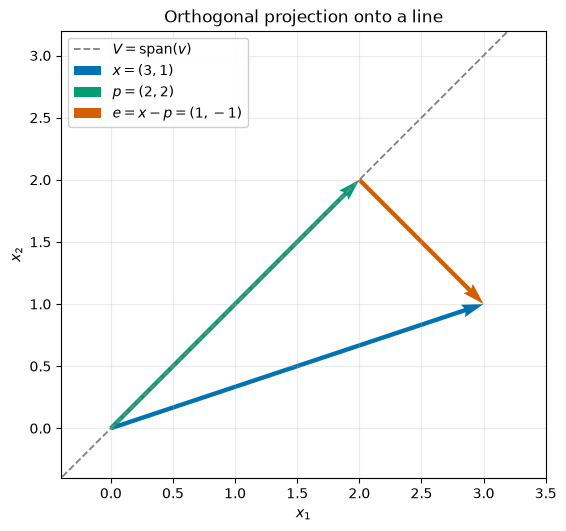

In [10]:
# 沿用上一单元的 x、v、projection 和 residual。
fig, ax = plt.subplots(figsize=(6.3, 5.2), layout="constrained")
# 虚线画出由 v 张成的直线，作为投影的目标子空间。
ax.plot(
    [-0.5, 3.5],
    [-0.5, 3.5],
    "--",
    color="0.5",
    linewidth=1.3,
    label=r"$V=\mathrm{span}(v)$",
)
# *x 展开两个方向分量；xy 坐标和 scale=1 让箭头按数据长度绘制。
ax.quiver(
    0,
    0,
    *x,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#0072B2",
    width=0.009,
    label=r"$x=(3,1)$",
)
# 投影向量也从原点出发，终点位于目标直线上。
ax.quiver(
    0,
    0,
    *projection,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#009E73",
    width=0.009,
    label=r"$p=(2,2)$",
)
# 残差箭头从投影终点出发，接到 x 的终点，展示 x = p + e。
ax.quiver(
    *projection,
    *residual,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#D55E00",
    width=0.009,
    label=r"$e=x-p=(1,-1)$",
)
ax.set(
    xlim=(-0.4, 3.5),
    ylim=(-0.4, 3.2),
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    title="Orthogonal projection onto a line",
)
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.legend(loc="upper left", framealpha=0.95)
# 残差从绿色箭头末端指向蓝色箭头末端，与虚线垂直。
plt.show()

### 5.3 为什么正交投影是最近点

设 $V$ 是 $\mathbb R^n$ 的线性子空间，$p\in V$，且 $e=x-p$ 与 $V$ 内所有向量正交。对任意 $z\in V$，有 $p-z\in V$，因此

$$\begin{aligned}
\|x-z\|_2^2
&=\|e+(p-z)\|_2^2\\
&=\|e\|_2^2+2e^T(p-z)+\|p-z\|_2^2\\
&=\|e\|_2^2+\|p-z\|_2^2
\geq\|e\|_2^2.
\end{aligned}$$

等号仅在 $z=p$ 时成立，所以 $p$ 是唯一的欧氏最近点。这一结论的关键是内积展开和正交条件，不能直接改成 1 范数或无穷范数。下面只用几个候选点观察推导的结论，有限次比较本身不是证明。

In [11]:
x = np.array([3.0, 1.0])
v = np.array([1.0, 1.0])
for coefficient in (0.0, 1.0, 2.0, 3.0):
    candidate = coefficient * v
    difference = x - candidate
    print(f"系数 {coefficient}，平方距离：", difference @ difference)  # 系数 0、1、2、3 的平方距离依次为 10、4、2、4。
# 依次为 10、4、2、4；系数为 2 时得到正交投影。

系数 0.0，平方距离： 10.0
系数 1.0，平方距离： 4.0
系数 2.0，平方距离： 2.0
系数 3.0，平方距离： 4.0


## 6 从一个方向扩展到子空间

### 6.1 标准正交基中的坐标与投影

设 $Q=[q_1\ \cdots\ q_k]\in\mathbb R^{m\times k}$ 的列是子空间 $V$ 的标准正交基，$x\in\mathbb R^m$。每个方向的投影系数是 $q_i^Tx$，合起来为 $c=Q^Tx\in\mathbb R^k$。对应投影为

$$p=Qc=QQ^Tx,\qquad e=x-p.$$

它在 $V$ 内，而且 $Q^Te=Q^Tx-Q^TQ Q^Tx=0$，所以残差与每个基向量都正交，也就与它们的任意线性组合正交。

取 $q_1=(1,1,0)^T/\sqrt2$、$q_2=(0,0,1)^T$，投影到的平面满足第一、第二分量相等。对 $x=(3,1,2)^T$，有 $c=(2\sqrt2,2)^T$、$p=(2,2,2)^T$、$e=(1,-1,0)^T$。

In [12]:
q1 = np.array([1.0, 1.0, 0.0]) / np.sqrt(2)
q2 = np.array([0.0, 0.0, 1.0])
Q = np.column_stack([q1, q2])
x = np.array([3.0, 1.0, 2.0])
coordinates = Q.T @ x
projection = Q @ coordinates
residual = x - projection

print("基中的坐标：", coordinates)  # [2√2, 2]，包含 2 个分量。
print("原空间的投影：", projection)  # [2, 2, 2]，包含 3 个分量。
print("正交残差：", residual)  # [1, -1, 0]。
print("各基向量与残差的内积：", Q.T @ residual)  # 仅有舍入量级误差。
print("残差正交：", np.allclose(Q.T @ residual, 0, atol=1e-12, rtol=0))  # 预期为 True。
print(
    "平方长度分解：", x @ x, projection @ projection + residual @ residual
)  # 都约为 14。

基中的坐标： [2.82842712 2.        ]
原空间的投影： [2. 2. 2.]
正交残差： [ 1. -1.  0.]
各基向量与残差的内积： [6.66133815e-16 0.00000000e+00]
残差正交： True
平方长度分解： 14.0 13.999999999999996


### 6.2 投影矩阵的性质

矩阵 $P=QQ^T\in\mathbb R^{m\times m}$ 把任意输入映射到 $V$。由 $Q^TQ=I_k$ 得到

$$P^T=(QQ^T)^T=P,\qquad
P^2=Q(Q^TQ)Q^T=QQ^T=P.$$

第一个等式是对称性；第二个等式称为幂等性（idempotence），表示投影后的向量再次投影不会改变。若 $k<m$，$Q^TQ=I_k$ 仍成立，但 $QQ^T$ 不是 $I_m$；投影会去掉垂直于 $V$ 的分量。

In [13]:
# 沿用上一单元的 Q、x、projection 和 residual。
P = Q @ Q.T
print("P：\n", P)  # 前两行各含两个 0.5，第三个坐标保持不变。
print("对称：", np.allclose(P.T, P, atol=1e-12, rtol=0))  # 预期为 True。
print("幂等：", np.allclose(P @ P, P, atol=1e-12, rtol=0))  # 预期为 True。
print("P 是三维单位矩阵：", np.allclose(P, np.eye(3), atol=1e-12, rtol=0))  # False。
print("再次投影：", P @ projection)  # 仍为 [2, 2, 2]。
print("残差的投影：", P @ residual)  # 接近零向量。

P：
 [[0.5 0.5 0. ]
 [0.5 0.5 0. ]
 [0.  0.  1. ]]
对称： True
幂等： True
P 是三维单位矩阵： False
再次投影： [2. 2. 2.]
残差的投影： [4.4408921e-16 4.4408921e-16 0.0000000e+00]


### 6.3 非单位和非正交基的边界

若 $u_1,\ldots,u_k$ 两两正交但长度不一定为 1，仍可以逐方向相加，不过必须保留分母：

$$p=\sum_{i=1}^{k}\frac{u_i^Tx}{u_i^Tu_i}u_i.$$

只知道基向量线性无关，不能套用这个求和式，因为不同方向的内积交叉项不再消失。下面先核对非单位正交基，再用一组非正交基观察错误套用的后果。

In [14]:
x = np.array([3.0, 1.0, 2.0])
u1 = np.array([1.0, 1.0, 0.0])
u2 = np.array([0.0, 0.0, 2.0])
projection = ((u1 @ x) / (u1 @ u1)) * u1 + ((u2 @ x) / (u2 @ u2)) * u2
print("正交基求出的投影：", projection)  # [2, 2, 2]。

# 反例：下面两个向量不正交，不能直接把两个方向的投影相加。
a = np.array([1.0, 0.0])
b = np.array([1.0, 1.0])
target = np.array([0.0, 1.0])
wrong_projection = ((a @ target) / (a @ a)) * a + ((b @ target) / (b @ b)) * b
print("错误套用得到：", wrong_projection)  # [0.5, 0.5]。
print("与第一个方向的残差内积：", a @ (target - wrong_projection))  # -0.5，不正交。
# a、b 张成整个二维平面，正确投影应是 target 自身。

正交基求出的投影： [2. 2. 2.]
错误套用得到： [0.5 0.5]
与第一个方向的残差内积： -0.5


## 7 矩阵的 Frobenius 范数与迹

### 7.1 把全部元素的平方加起来

对于 $A\in\mathbb R^{m\times n}$，Frobenius 范数（弗罗贝尼乌斯范数）定义为

$$\|A\|_F=\sqrt{\sum_{i=1}^{m}\sum_{j=1}^{n}A_{ij}^2}.$$

它相当于把矩阵所有元素排成一个向量后取欧氏长度，适合汇总矩阵误差。矩阵不必为方阵；下例 $3\times2$ 矩阵的平方范数是 $1+4+0+1+4+0=10$。

代码用 np.linalg.norm(A, ord="fro") 明确指定含义。二维输入的 ord=2 表示另一种矩阵范数，不能把“向量的 2 范数”写法直接当成 Frobenius 范数。

In [15]:
A = np.array([[1.0, 2.0], [0.0, -1.0], [2.0, 0.0]])
sum_of_squares = np.sum(A**2)

print("A 的形状：", A.shape)  # (3, 2)。
print("逐元素平方和：", sum_of_squares)  # 10。
print("Frobenius 范数：", np.linalg.norm(A, ord="fro"))  # √10。
print("展开后的欧氏长度：", np.linalg.norm(A.ravel()))  # 同为 √10。

A 的形状： (3, 2)
逐元素平方和： 10.0
Frobenius 范数： 3.1622776601683795
展开后的欧氏长度： 3.1622776601683795


### 7.2 迹与基本性质

方阵 $M\in\mathbb R^{r\times r}$ 的迹（trace）是主对角线之和：$\operatorname{tr}(M)=\sum_{i=1}^{r}M_{ii}$，其中 $r$ 为正整数。它是标量，不是整个矩阵所有元素的和。

对同形方阵 $M,N$ 和实数 $a,b$，有 $\operatorname{tr}(aM+bN)=a\operatorname{tr}(M)+b\operatorname{tr}(N)$；转置不改变对角元，因此 $\operatorname{tr}(M^T)=\operatorname{tr}(M)$。

若 $A\in\mathbb R^{m\times n}$、$B\in\mathbb R^{n\times m}$，则 $AB$ 与 $BA$ 虽然形状不同，仍有 $\operatorname{tr}(AB)=\operatorname{tr}(BA)$。这是对求和指标换序得到的标量关系，不表示 $AB=BA$。多个因子可循环移动；例如另取同阶方阵 $A,B,C$，有 $\operatorname{tr}(ABC)=\operatorname{tr}(BCA)$，但不能任意重排。

In [16]:
M = np.array([[1.0, 2.0], [3.0, 4.0]])
N = np.array([[0.0, 1.0], [-1.0, 2.0]])
print("M 的迹：", np.trace(M))  # 1 + 4 = 5。
print("转置后的迹：", np.trace(M.T))  # 仍为 5。
print("线性组合的迹：", np.trace(2 * M - N), 2 * np.trace(M) - np.trace(N))  # 都为 8。

A = np.array([[1.0, 2.0], [0.0, -1.0], [2.0, 0.0]])
B = np.array([[1.0, 0.0, 1.0], [0.0, 2.0, -1.0]])
print("AB 与 BA 的形状：", (A @ B).shape, (B @ A).shape)  # (3, 3) 与 (2, 2)。
print("AB 与 BA 的迹：", np.trace(A @ B), np.trace(B @ A))  # 同为 1。

M 的迹： 5.0
转置后的迹： 5.0
线性组合的迹： 8.0 8.0
AB 与 BA 的形状： (3, 3) (2, 2)
AB 与 BA 的迹： 1.0 1.0


### 7.3 平方范数的迹表达式

$A^TA$ 是 $n\times n$ 方阵，其第 $j$ 个对角元是第 $j$ 列的平方和，所以

$$\operatorname{tr}(A^TA)
=\sum_{j=1}^{n}(A^TA)_{jj}
=\sum_{j=1}^{n}\sum_{i=1}^{m}A_{ij}^2
=\|A\|_F^2
=\operatorname{tr}(AA^T).$$

其中 $AA^T$ 是 $m\times m$ 方阵。对列向量 $x\in\mathbb R^n$，同样有 $\|x\|_2^2=x^Tx=\operatorname{tr}(xx^T)$；$x^Tx$ 是标量，而 $xx^T$ 是 $n\times n$ 矩阵。

代码中显式构造二维列数组来表示外积。对一维数组，x @ x 得到标量，x.T 不会把它变成二维列或行矩阵。

In [17]:
A = np.array([[1.0, 2.0], [0.0, -1.0], [2.0, 0.0]])
print("元素平方和：", np.sum(A**2))  # 预期为 10。
print("tr(AᵀA)：", np.trace(A.T @ A))  # 预期为 10。
print("tr(AAᵀ)：", np.trace(A @ A.T))  # 预期为 10。
# 上面三项均为 10；两个乘积的形状不同，迹相同。

x = np.array([3.0, 4.0])
x_column = x[:, None]
outer_product = x_column @ x_column.T
print("xxᵀ：\n", outer_product)  # [[9, 12], [12, 16]]。
print("xᵀx 与 tr(xxᵀ)：", x @ x, np.trace(outer_product))  # 均为 25。

元素平方和： 10.0
tr(AᵀA)： 10.0
tr(AAᵀ)： 10.0
xxᵀ：
 [[ 9. 12.]
 [12. 16.]]
xᵀx 与 tr(xxᵀ)： 25.0 25.0


## 8 综合应用：比较一批向量的投影误差

下面使用三个人工构造的三维向量，考察把第一、第二分量限制为相等后，保留的信息与舍弃的误差。将每个输入放在矩阵 $X\in\mathbb R^{3\times3}$ 的一列；$Q\in\mathbb R^{3\times2}$ 的列仍是目标平面的标准正交基。

整批投影为 $\widehat X=Q(Q^TX)$，残差矩阵为 $E=X-\widehat X$。每列残差应与目标平面正交，因此检查 $Q^TE$ 是否接近零。

全部平方误差既可按列累计 $\sum_{j=1}^{3}\|E_{:,j}\|_2^2$，也可写成 $\|E\|_F^2=\operatorname{tr}(E^TE)$。这里 $E_{:,j}$ 表示第 $j$ 列；这几种写法度量的是同一批误差。

In [18]:
X = np.array([[3.0, 1.0, 0.0], [1.0, 3.0, 2.0], [2.0, 0.0, 1.0]])
Q = np.column_stack(
    [
        np.array([1.0, 1.0, 0.0]) / np.sqrt(2),
        np.array([0.0, 0.0, 1.0]),
    ]
)
projected = Q @ (Q.T @ X)
errors = X - projected
column_squared_errors = np.sum(errors**2, axis=0)

print("投影后的各列：\n", projected)  # 每列第一、第二分量相等，第三分量不变。
print("各列平方误差：", column_squared_errors)  # [2, 2, 2]。
print("逐列累计：", np.sum(column_squared_errors))  # 约为 6。
print("Frobenius 平方：", np.linalg.norm(errors, ord="fro") ** 2)  # 约为 6。
print("迹形式：", np.trace(errors.T @ errors))  # 约为 6。
print("所有残差均正交：", np.allclose(Q.T @ errors, 0, atol=1e-12, rtol=0))  # True。
print(
    "矩阵平方范数分解：", np.sum(X**2), np.sum(projected**2) + np.sum(errors**2)
)  # 均约为 29。

投影后的各列：
 [[2. 2. 1.]
 [2. 2. 1.]
 [2. 0. 1.]]
各列平方误差： [2. 2. 2.]
逐列累计： 6.0
Frobenius 平方： 5.999999999999999
迹形式： 6.0
所有残差均正交： True
矩阵平方范数分解： 29.0 28.999999999999993


## 本章小结

（1）标准欧氏内积把分量关系压缩成标量，并给出长度、欧氏距离与非零向量的夹角。归一化公式只适用于非零向量。

（2）1 范数、2 范数、无穷范数表达不同的大小与距离；平方欧氏范数不满足范数的数乘规则。

（3）正交投影同时满足“投影在子空间内”和“残差与子空间正交”，因此是唯一的欧氏最近点。使用逐方向投影公式前，要确认基向量的正交性与长度。

（4）Frobenius 平方范数可由逐元素平方和、逐列平方长度和以及迹计算。表达式看起来不同，形状与求和对象必须对应。

自查：为什么 $Q^TQ=I$ 不一定有 $QQ^T=I$？为什么改变范数后，不能直接沿用欧氏最近点的证明？

## 练习

（1）长度、方向与零向量

分别计算向量 (6, 8)、(-3, -4)、(0, 0) 的长度，并把前两个非零向量转换为单位向量。计算前两个向量的夹角，说明为什么第三个向量不能参与同样的夹角计算。

核对标准：所有成功归一化的向量长度都接近 1；夹角的结果应与方向判断一致；零向量只计算长度，不代入没有定义的归一化与夹角公式。

In [19]:
vectors = [np.array([6.0, 8.0]), np.array([-3.0, -4.0]), np.zeros(2)]
# 补充：分别计算长度，只归一化前两个向量，再计算它们的夹角。
# 最后用一句话说明零向量不适用上述公式的原因。

（2）换一个方向向量，投影会改变吗

把 $x=(2,3)^T$ 投影到 $v=(2,1)^T$ 张成的直线，先手算系数、投影和残差，再把方向向量改为 $-3v$ 重复计算。

核对标准：两个系数不同，两个投影相同；残差与直线方向的内积接近零。解释为什么不能只比较投影系数来判断投影是否相同。

In [20]:
x = np.array([2.0, 3.0])
v = np.array([2.0, 1.0])
scaled_v = -3 * v
# 补充：分别计算两种方向表示下的系数与投影，核对残差正交性。

（3）把距离换成 1 范数

仍取 $x=(3,1)^T$，直线上的点为 $z(t)=(t,t)^T$，其中 $t\in\mathbb R$。写出 $d_1(x,z(t))=|3-t|+|1-t|$，比较 $t=1,1.5,2,2.5,3$ 的距离，再对区间 $1\leq t\leq3$ 化简公式。

核对标准：解释这些点为什么有相同的 1 范数距离，并判断它们是否都是最近点。欧氏投影的“唯一最近点”结论在哪个条件上发生了变化？

In [21]:
x = np.array([3.0, 1.0])
parameters = [1.0, 1.5, 2.0, 2.5, 3.0]
# 补充：计算各候选点的 1 范数距离，并用分段表达式判断全部最近点。

（4）用三种写法累计矩阵误差

下面 E 的每一列是一条二维误差向量。分别用逐元素平方和、逐列欧氏长度的平方和、迹形式计算总平方误差；再把第一列扩大 2 倍，判断总误差会怎样变化。

核对标准：三种计算方式一致；改变一列时，只该列的平方误差变为原来的 4 倍。解释为什么不能直接把整个总误差乘以 4。

In [22]:
E = np.array([[1.0, -2.0, 0.0], [2.0, 1.0, -1.0]])
# 补充：先按三种方式累计误差，再复制矩阵并改变第一列进行比较。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：投影系数由方向向量与待投影向量的内积决定。

提示 2：方向向量乘以非零常数时，系数会反向缩放；比较的是系数与方向的乘积。

### 练习（2）参考解析

对 $v=(2,1)^T$，系数为 $c=(v^Tx)/(v^Tv)=7/5$，投影 $p=cv=(14/5,7/5)^T$。取残差 $r=x-p=(-4/5,8/5)^T$，有 $v^Tr=0$。

改用 $w=-3v$ 后，系数为 $(w^Tx)/(w^Tw)=-7/15$，乘回 w 仍得到 p，且 $w^Tr=0$。直线没有改变，投影也没有改变；系数依赖于所选方向向量的长度和符号。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Georgia Tech — Interactive Linear Algebra | [§6.1 Dot Products and Orthogonality](https://textbooks.math.gatech.edu/ila/dot-product.html)：§6.1.1 的内积、长度、距离与单位向量，§6.1.2 的正交与夹角；[§6.3 Orthogonal Projection](https://textbooks.math.gatech.edu/ila/projections.html)：Orthogonal Decomposition、投影到直线的推导、Closest Vector 与 Projection Matrices；[§6.4 Orthogonal Sets](https://textbooks.math.gatech.edu/ila/orthogonal-sets.html)：§6.4.1 正交集、标准正交集、线性无关证明与投影公式的条件。 |
| Fundamentals of Numerical Computation | [§2.7 Norms](https://fncbook.com/norms/)：§2.7.1 范数性质，Definition 2.7.1 的 1、2、无穷范数，Definition 2.7.2 的单位向量。 |
| Deep Learning — 作者提供的教材 | [第 2 章 Linear Algebra](https://www.deeplearningbook.org/contents/linear_algebra.html)：§2.5 Norms 的 p 范数、平方欧氏范数和 Frobenius 范数（式 2.33）；§2.10 Trace Operator 的定义、转置与循环性质及平方范数的迹表达式（式 2.48–2.53）。 |
| NumPy 2.5 官方文档 | [numpy.linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) 的 Parameters、Notes 范数表；[numpy.trace](https://numpy.org/doc/stable/reference/generated/numpy.trace.html) 的二维对角线求和；[numpy.arccos](https://numpy.org/doc/stable/reference/generated/numpy.arccos.html)、[numpy.degrees](https://numpy.org/doc/stable/reference/generated/numpy.degrees.html) 的定义域与单位转换；[numpy.meshgrid](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) 的坐标网格；[numpy.allclose](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html) 的 Notes 容差条件。 |
| Matplotlib 3.11 官方文档 | [Axes.contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contour.html) 的 X、Y、Z 和 levels；[Axes.quiver](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.quiver.html) 的 angles、scale_units 与 scale；[Axes.set_aspect](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_aspect.html) 的 equal；[pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) 与 [pyplot.show](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html) 的图形创建和展示。 |